<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">



# **Analisis de Series de Tiempo II**

# **Clase 5, Temporal Convolution Network**

Se utilizará el dataset de AirPassengers el cual maneja el numero de pasajeros mensuales de una aerolinea entre 1949 y 1960

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

flights = sns.load_dataset('flights')
serie_np = flights['passengers'].values.astype('float32')

media, std = serie_np.mean(), serie_np.std()
serie_norm = (serie_np - media) / std

serie = torch.tensor(serie_norm).unsqueeze(0).unsqueeze(0)  # (batch, canales, tiempo)

print('Cantidad de puntos:', len(serie_np))

Cantidad de puntos: 144


Realizamos Holdout

In [ ]:
n_total = serie.shape[2]
n_train = int(n_total * 0.8)

serie_train = serie[:, :, :n_train]
x_train = serie_train[:, :, :-1]
y_train = serie_train[:, :, 1:]

Bloques del TCN

In [ ]:
def causal_conv1d(in_c, out_c, k, d):
    pad = (k - 1) * d
    conv = nn.Conv1d(in_c, out_c, k, padding=pad, dilation=d)
    return conv, pad

def chomp(x, pad):
    return x[:, :, :-pad] if pad > 0 else x

def tcn_block(x, conv, pad, es_ultima):
    x = chomp(conv(x), pad)
    if es_ultima:
        return x
    return F.leaky_relu(x, 0.1)

def build_tcn(in_c, channels, k=3):
    layers = []
    c_in = in_c
    for i, c_out in enumerate(channels):
        d = 2 ** i
        conv, pad = causal_conv1d(c_in, c_out, k, d)
        layers.append((conv, pad))
        c_in = c_out
    return layers

def tcn_forward(x, layers):
    n = len(layers)
    for i, (conv, pad) in enumerate(layers):
        x = tcn_block(x, conv, pad, es_ultima=(i == n - 1))
    return x

Realiza el entrenamiento con horizonte = 1 (mes adelante) y comparalo con el naive baseline. Luego realiza la misma comparación pero con horizonte = 6.

**Horizonte = 1**

In [ ]:
torch.manual_seed(0)
layers = build_tcn(in_c=1, channels=[16, 32, 1], k=3)
params = [p for conv, _ in layers for p in conv.parameters()]
opt = torch.optim.Adam(params, lr=0.003)

for epoch in range(1500):
    opt.zero_grad()
    y_pred = tcn_forward(x_train, layers)
    loss = torch.mean((y_pred - y_train) ** 2)
    loss.backward()
    opt.step()
    if epoch % 250 == 0:
        print(epoch, loss.item())

0 0.5100175142288208
250 0.003908918239176273
500 0.0018660812638700008
750 0.0011794816236943007
1000 0.00082934251986444
1250 0.000539616507012397


Evaluación

In [ ]:
with torch.no_grad():
    pred_completa = tcn_forward(serie[:, :, :-1], layers)
    pred_test_norm = pred_completa[:, :, n_train - 1:].squeeze().numpy()

y_test_real = serie_np[n_train:]
pred_test_real = pred_test_norm * std + media

mse_test_h1 = np.mean((pred_test_real - y_test_real) ** 2)
print('\nMSE en test (horizonte=1):', mse_test_h1)


MSE en test (horizonte=1): 756.96405


**Naive Baseline (horizonte=1)**

In [ ]:
pred_naive_test = serie_np[n_train - 1:-1]
mse_naive_test = np.mean((pred_naive_test - y_test_real) ** 2)
print('MSE ingenuo en test (copiar mes anterior):', mse_naive_test)

MSE ingenuo en test (copiar mes anterior): 2755.3447


---

**Horizonte = 6 meses (medio ciclo anual)**

In [ ]:
horizonte = 6

x_h = serie[:, :, :-horizonte]
y_h = serie[:, :, horizonte:]

x_h_train = x_h[:, :, :n_train - horizonte]
y_h_train = y_h[:, :, :n_train - horizonte]
x_h_test = x_h[:, :, n_train - horizonte:]
y_h_test = y_h[:, :, n_train - horizonte:]

In [ ]:
torch.manual_seed(0)
layers_h = build_tcn(in_c=1, channels=[16, 32, 1], k=3)
params_h = [p for conv, _ in layers_h for p in conv.parameters()]
opt_h = torch.optim.Adam(params_h, lr=0.003)

Entrenamiento

In [ ]:
for epoch in range(1500):
    opt_h.zero_grad()
    y_pred_h = tcn_forward(x_h_train, layers_h)
    loss_h = torch.mean((y_pred_h - y_h_train) ** 2)
    loss_h.backward()
    opt_h.step()
    if epoch % 250 == 0:
        print(epoch, loss_h.item())

0 0.49488019943237305
250 0.005725080147385597
500 0.003571543376892805
750 0.002037770813331008
1000 0.001053990563377738
1250 0.0006637495825998485


Evaluación

In [ ]:
with torch.no_grad():
    pred_h_test_norm = tcn_forward(x_h_test, layers_h).squeeze().numpy()

y_h_test_real = y_h_test.squeeze().numpy() * std + media
pred_h_test_real = pred_h_test_norm * std + media

mse_test_hN = np.mean((pred_h_test_real - y_h_test_real) ** 2)

pred_naive_hN = x_h_test.squeeze().numpy() * std + media
mse_naive_hN = np.mean((pred_naive_hN - y_h_test_real) ** 2)

print(f'\nMSE en test (horizonte={horizonte}):', mse_test_hN)
print(f'MSE ingenuo en test (horizonte={horizonte}):', mse_naive_hN)


MSE en test (horizonte=6): 8324.449
MSE ingenuo en test (horizonte=6): 14175.586


Graficos

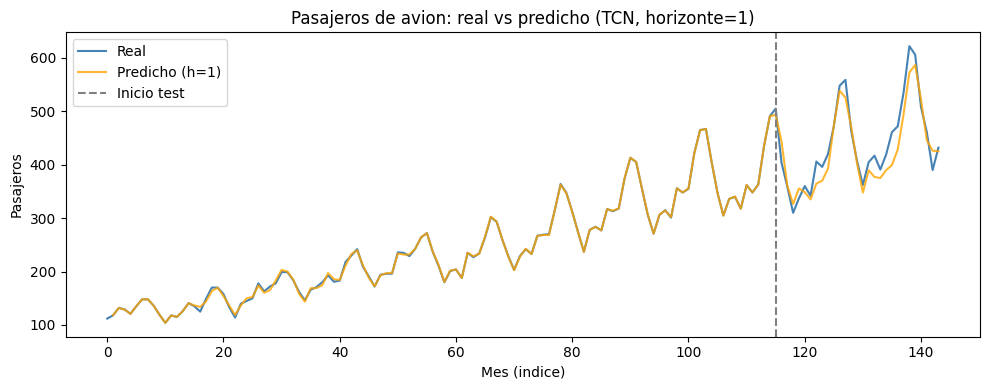

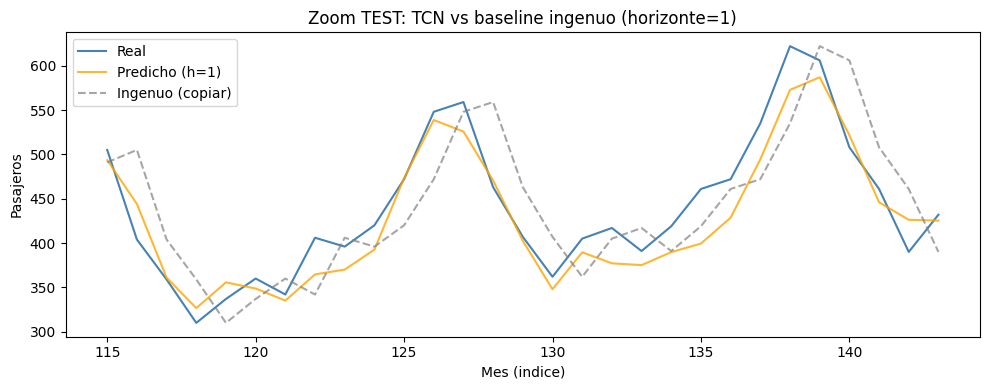

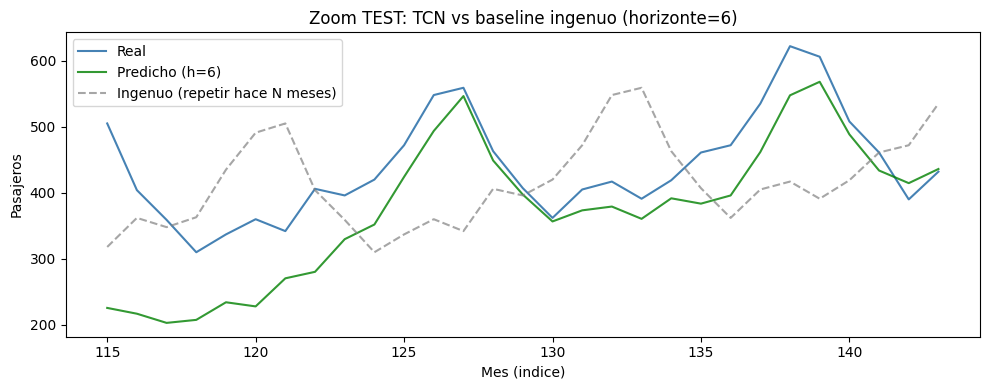

In [ ]:
t = np.arange(len(serie_np))

plt.figure(figsize=(10, 4))
plt.plot(t, serie_np, label='Real', color='steelblue')
plt.plot(t[1:], pred_completa.squeeze().numpy() * std + media, label='Predicho (h=1)', color='orange', alpha=0.8)
plt.axvline(t[n_train], color='gray', linestyle='--', label='Inicio test')
plt.title('Pasajeros de avion: real vs predicho (TCN, horizonte=1)')
plt.xlabel('Mes (indice)')
plt.ylabel('Pasajeros')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(t[n_train:], y_test_real, label='Real', color='steelblue')
plt.plot(t[n_train:], pred_test_real, label='Predicho (h=1)', color='orange', alpha=0.8)
plt.plot(t[n_train:], pred_naive_test, label='Ingenuo (copiar)', color='gray', linestyle='--', alpha=0.7)
plt.title('Zoom TEST: TCN vs baseline ingenuo (horizonte=1)')
plt.xlabel('Mes (indice)')
plt.ylabel('Pasajeros')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
eje_x_h = t[n_train:]
plt.plot(eje_x_h, y_h_test_real, label='Real', color='steelblue')
plt.plot(eje_x_h, pred_h_test_real, label=f'Predicho (h={horizonte})', color='green', alpha=0.8)
plt.plot(eje_x_h, pred_naive_hN, label='Ingenuo (repetir hace N meses)', color='gray', linestyle='--', alpha=0.7)
plt.title(f'Zoom TEST: TCN vs baseline ingenuo (horizonte={horizonte})')
plt.xlabel('Mes (indice)')
plt.ylabel('Pasajeros')
plt.legend()
plt.tight_layout()
plt.show()